# Demonstrating the Limitations of ComBat

## Overview

ComBat is a widely used harmonization method that removes scanner/site effects using a **location–scale model with empirical Bayes estimation**.

It relies on several key assumptions:
- **linear covariate effects**  
- **additive and multiplicative (location–scale) scanner effects**  
- **discrete scanner/site grouping**  

While effective in many settings, these assumptions can be violated in realistic neuroimaging data.

---

## Strategy

We use simulated data with known ground truth to systematically evaluate where ComBat breaks down.

---

### **Step 1 — Nonlinear biological effects**

We generate data with:
- nonlinear biological relationships (e.g. age²)

**Goal:**  
→ Show that ComBat cannot correctly preserve biological signal when covariate effects are nonlinear.

---

### **Step 2 — False positive rate (FPR) inflation under confounding**

We simulate:
- correlation between scanner and biological variables  

We introduce:
- a **null variable with no true effect**

**Goal:**  
→ Show that ComBat can introduce **spurious associations (false positives)** when scanner and biology are not independent.

---

### **Step 3 — Limitations of discrete scanner modeling**

We simulate:
- **continuous scanner variation** (e.g. acquisition quality, drift)
- **within-scanner heterogeneity**

**Goal:**  
→ Show that treating scanners as discrete groups is insufficient to capture realistic acquisition variability.

---


## Key message

The limitations observed here are not specific to ComBat alone, but arise from the broader class of **location–scale harmonization models**.

In [ ]:
# Install if needed
# !pip install neuroCombat

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from neuroCombat import neuroCombat
from sklearn.metrics import mean_squared_error
from scipy.stats import ttest_ind

np.random.seed(42)

## Step 1 — Nonlinear biological effects

The key feature:
→ The biological effect is **nonlinear**

This intentionally violates ComBat’s assumption of **linear covariate effects**.

In [45]:
n = 800
n_features = 20   # number of IDPs

# Biological variables
age = np.random.uniform(20, 80, n)
sex = np.random.binomial(1, 0.5, n)
disease = np.random.binomial(1, 0.3, n)

# Scanner
scanner = np.random.choice(['A', 'B', 'C'], size=n)
scanner_map = {'A': 0, 'B': 1, 'C': 2}
scanner_num = np.array([scanner_map[s] for s in scanner])

# Base biological components
bio_age = 0.05 * (age - 50)**2
bio_sex = 2 * sex
bio_disease = 5 * disease
bio_interaction = 0.03 * age * disease

base_bio = bio_age + bio_sex + bio_disease + bio_interaction

# Create feature-specific variations
Y_true = []

for j in range(n_features):
    scale = np.random.uniform(0.8, 1.2)
    offset = np.random.normal(0, 1)
    
    y_j = scale * base_bio + offset
    Y_true.append(y_j)

Y_true = np.array(Y_true)   # shape (features, samples)

Y_obs = []

for j in range(n_features):
    
    # Additive scanner effect
    scanner_effect = scanner_num * np.random.uniform(1.5, 3)
    
    # Interaction (scanner × age)
    interaction = scanner_num * np.random.uniform(0.01, 0.05) * age
    
    # Continuous scanner variation (IQM-like)
    scanner_quality = scanner_num + np.random.normal(0, 0.5, n)
    drift = np.random.uniform(1, 3) * scanner_quality
    
    # Heteroskedastic noise
    noise = np.random.normal(0, 1 + 0.02 * age, n)
    
    y_obs_j = Y_true[j] + scanner_effect + interaction + drift + noise
    Y_obs.append(y_obs_j)

Y_obs = np.array(Y_obs)

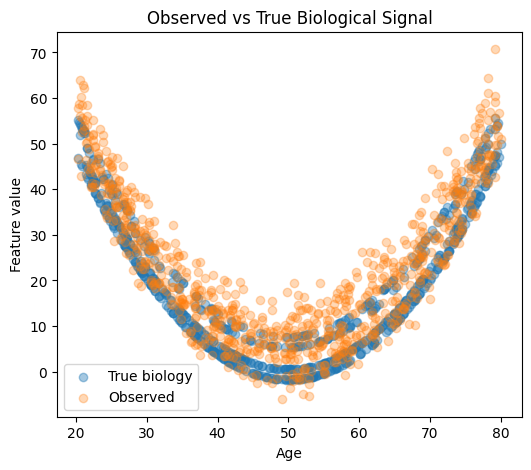

In [46]:
feature_idx = 0

plt.figure(figsize=(6,5))

plt.scatter(age, Y_true[feature_idx], alpha=0.4, label='True biology')
plt.scatter(age, Y_obs[feature_idx], alpha=0.3, label='Observed')

plt.legend()
plt.title("Observed vs True Biological Signal")
plt.xlabel("Age")
plt.ylabel("Feature value")
plt.show()

### Apply ComBat

In [47]:
covars = pd.DataFrame({
    'batch': scanner,
    'age': age,
    'sex': sex,
    'disease': disease
})

combat_result = neuroCombat(
    dat=Y_obs,
    covars=covars,
    batch_col='batch',
    continuous_cols=['age'],
    categorical_cols=['sex', 'disease']
)

Y_combat = combat_result['data']

[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data


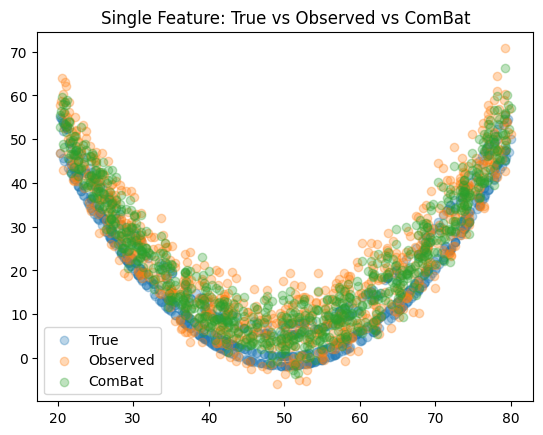

In [48]:
# Visualize One Feature
feature_idx = 0

plt.scatter(age, Y_true[feature_idx], alpha=0.3, label='True')
plt.scatter(age, Y_obs[feature_idx], alpha=0.3, label='Observed')
plt.scatter(age, Y_combat[feature_idx], alpha=0.3, label='ComBat')

plt.legend()
plt.title("Single Feature: True vs Observed vs ComBat")
plt.show()

In [64]:
rmse_raw = []
rmse_combat = []

for j in range(n_features):
    rmse_raw.append(
        np.sqrt(mean_squared_error(Y_obs[j], Y_combat[j]))
    )
    rmse_combat.append(
        np.sqrt(mean_squared_error(Y_true[j], Y_combat[j]))
    )

print("Mean RMSE with Observed Data:", np.mean(rmse_raw))
print("Mean RMSE with True Biology:", np.mean(rmse_combat))


Mean RMSE with Observed Data: 4.469685700975896
Mean RMSE with True Biology: 5.967455855479911


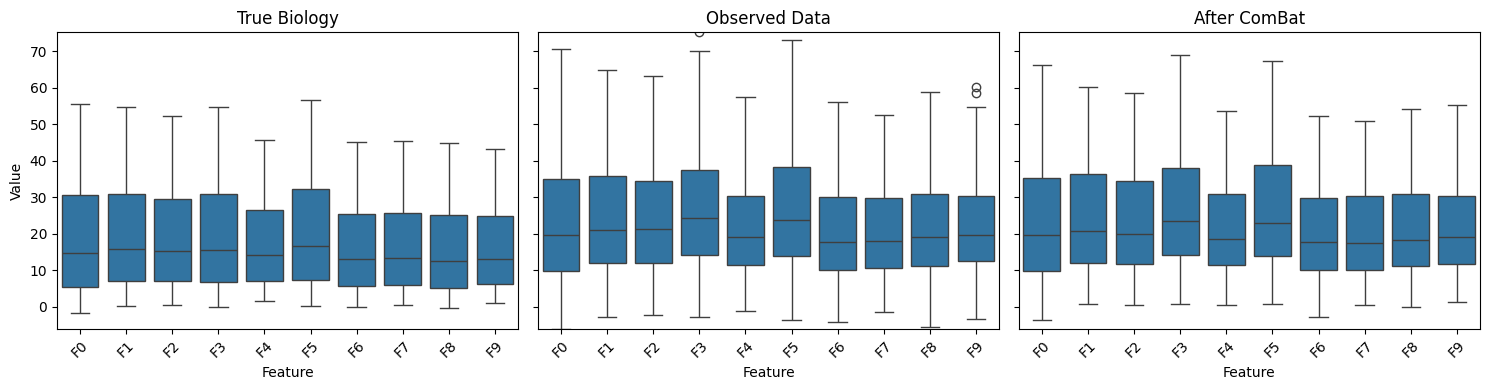

In [63]:
# Number of features to display (e.g. first 10)
n_display = 10

# Convert matrices to long format
def to_long(Y, label):
    data = []
    for j in range(n_display):
        for val in Y[j]:
            data.append({
                'feature': f'F{j}',
                'value': val,
                'type': label
            })
    return pd.DataFrame(data)

df_true = to_long(Y_true, 'True')
df_obs = to_long(Y_obs, 'Observed')
df_combat = to_long(Y_combat, 'ComBat')

# Get global y-axis limits
ymin = min(df_true['value'].min(), df_obs['value'].min(), df_combat['value'].min())
ymax = max(df_true['value'].max(), df_obs['value'].max(), df_combat['value'].max())

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# Plot 1 — True biology
sns.boxplot(ax=axes[0], data=df_true, x='feature', y='value')
axes[0].set_title("True Biology")

# Plot 2 — Observed
sns.boxplot(ax=axes[1], data=df_obs, x='feature', y='value')
axes[1].set_title("Observed Data")

# Plot 3 — ComBat
sns.boxplot(ax=axes[2], data=df_combat, x='feature', y='value')
axes[2].set_title("After ComBat")

# Same y-axis limits
for ax in axes:
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel("Feature")
    ax.tick_params(axis='x', rotation=45)

axes[0].set_ylabel("Value")
axes[1].set_ylabel("")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

### Final Interpretation

ComBat:
- reduces scanner mean differences ✔
- reduces variance ✔

BUT:

- does not recover true biological signal ❌  
- fails under nonlinear effects and interactions ❌  
- ignores continuous scanner variation ❌  

---

## Key takeaway

Even in a realistic multi-feature setting:

→ ComBat improves data appearance  
→ but does not guarantee biological validity  


## Step 2 — False positive rate (FPR) inflation under confounding

### Motivation

In real datasets:
- scanner/site is often **correlated with biological variables**
  - e.g. different hospitals recruit different populations

ComBat assumes:
- scanner effects are independent of biological effects

---

### What we test

We simulate a setting where:
- scanner and biology are correlated
- there is **no true group effect**

We then test whether ComBat:
→ introduces false positives

To obtain a reliable estimate of the false positive rate, we repeat the entire simulation multiple times with different random seeds.

This ensures that observed effects are not due to random fluctuations.

---

We report:
- FPR per simulation
- distribution of FPR across runs

Expected:
- If ComBat is valid → FPR ≈ 0.05  
- If assumptions are violated → FPR > 0.05

---

### Key question

Does ComBat create spurious associations when its assumptions are violated?

In [113]:
def run_fpr_simulation(seed, n=800, n_features=20):
    
    np.random.seed(seed)

    scanner = np.random.choice(['A','B','C'], size=n)
    scanner_map = {'A':0,'B':1,'C':2}
    scanner_num = np.array([scanner_map[s] for s in scanner])

    # correlated age
    age = np.zeros(n)
    for i, s in enumerate(scanner):
        if s == 'A':
            age[i] = np.random.normal(30, 5)
        elif s == 'B':
            age[i] = np.random.normal(50, 5)
        else:
            age[i] = np.random.normal(70, 5)

    sex = np.random.binomial(1, 0.5, n)
    disease = np.random.binomial(1, 0.3, n)

    # TRUE BIO
    bio = (
        0.05 * (age - 50)**2 +
        2 * sex +
        5 * disease +
        0.03 * age * disease
    )

    Y_obs = []

    for j in range(n_features):
        scanner_effect = scanner_num * np.random.uniform(1.5, 3)
        interaction = scanner_num * 0.08 * age
        noise = np.random.normal(0, 2, n)

        y_j = bio + scanner_effect + interaction + noise
        Y_obs.append(y_j)

    Y_obs = np.array(Y_obs)

    # null group
    group = np.random.binomial(1, 0.5, n)

    covars = pd.DataFrame({
        'batch': scanner,
        'age': age,
        'sex': sex,
        'disease': disease
    })

    combat_result = neuroCombat(
        dat=Y_obs,
        covars=covars,
        batch_col='batch',
        continuous_cols=['age'],
        categorical_cols=['sex','disease']
    )

    Y_combat = combat_result['data']

    # -----------------------------
    # P-values
    # -----------------------------
    pvals = []

    for j in range(n_features):
        p = ttest_ind(
            Y_combat[j][group == 0],
            Y_combat[j][group == 1]
        ).pvalue
        pvals.append(p)

    pvals = np.array(pvals)

    # -----------------------------
    # Correlations (KEY ADDITION)
    # -----------------------------
    corr_scanner_age = np.corrcoef(scanner_num, age)[0,1]
    corr_scanner_bio = np.corrcoef(scanner_num, bio)[0,1]
    corr_scanner_group = np.corrcoef(scanner_num, group)[0,1]

    return pvals, corr_scanner_age, corr_scanner_bio, corr_scanner_group

In [114]:
n_runs = 1000
n_features = 20


pvals_matrix = np.zeros((n_features, n_runs))

corr_age_list = []
corr_bio_list = []
corr_group_list = []

for i in range(n_runs):
    pvals, c_age, c_bio, c_group = run_fpr_simulation(seed=i)
    
    pvals_matrix[:, i] = pvals
    
    corr_age_list.append(c_age)
    corr_bio_list.append(c_bio)
    corr_group_list.append(c_group)

[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S mode

In [115]:
print("Mean correlation scanner-age:", np.mean(corr_age_list))
print("Mean correlation scanner-bio:", np.mean(corr_bio_list))
print("Mean correlation scanner-group:", np.mean(corr_group_list))

alpha = 0.05

fpr_per_feature = np.mean(pvals_matrix < alpha, axis=1)

print("FPR per feature:", fpr_per_feature)

Mean correlation scanner-age: 0.9561858887335455
Mean correlation scanner-bio: 0.010570842112877921
Mean correlation scanner-group: -0.0017107082380752251
FPR per feature: [0.055 0.057 0.055 0.063 0.055 0.058 0.055 0.061 0.056 0.055 0.062 0.065
 0.053 0.06  0.061 0.053 0.058 0.057 0.055 0.06 ]


In [116]:
alpha = 0.05       # nominal FPR
N = 1000           # number of simulations (or tests)

# standard deviation under binomial
std = np.sqrt(alpha * (1 - alpha) / N)

# one-sided 95% bound (z = 1.645)
lower = alpha - 1.645 * std
upper = alpha + 1.645 * std

print("Lower bound:", lower)
print("Upper bound:", upper)

Lower bound: 0.03866261990140579
Upper bound: 0.06133738009859421


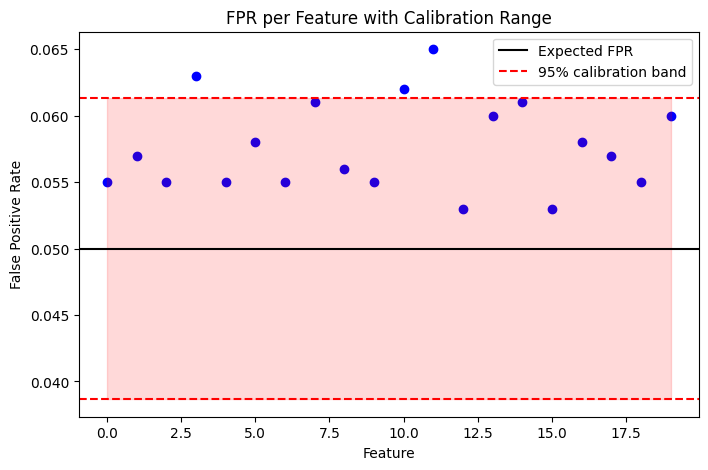

In [117]:
# x-axis: feature index
x = np.arange(len(fpr_per_feature))

plt.figure(figsize=(8,5))

# scatter: one dot per feature
plt.scatter(x, fpr_per_feature, color='blue')

# expected FPR
plt.axhline(alpha, color='black', label='Expected FPR')

# calibration band
plt.axhline(lower, color='red', linestyle='--', label='95% calibration band')
plt.axhline(upper, color='red', linestyle='--')

# optional: shade region (nicer)
plt.fill_between(x, lower, upper, color='red', alpha=0.15)

plt.xlabel("Feature")
plt.ylabel("False Positive Rate")
plt.title("FPR per Feature with Calibration Range")

plt.legend()
plt.show()

### Final Interpretation

ComBat:
- 

BUT:

-  

---

## Key takeaway

## Step 3 — Limitations of Discrete Scanner Modeling

### Motivation

ComBat models scanner effects using **discrete scanner identifiers**.

However, in real neuroimaging data:
- scanner-related variability is often **continuous**
  - e.g. signal-to-noise ratio (SNR)
  - contrast-to-noise ratio (CNR)
  - acquisition drift
- and varies **within scanner**

---

### Simulation design

We generate:
- discrete scanner IDs (A, B, C)
- a continuous latent variable representing scanner quality

The true scanner effect depends on this continuous variable,
not just the scanner label.

---

### Goal

Show that:
→ ComBat cannot remove scanner effects it cannot represent

In [120]:
n = 800
n_features = 20

# scanner IDs
scanner = np.random.choice(['A','B','C'], size=n)
scanner_map = {'A':0,'B':1,'C':2}
scanner_num = np.array([scanner_map[s] for s in scanner])

# continuous scanner variation (IQM-like)
scanner_quality = (
    scanner_num +
    np.random.normal(0, 0.8, n)   # large within-scanner variation
)

age = np.random.uniform(20, 80, n)
sex = np.random.binomial(1, 0.5, n)

true_bio = (
    0.05 * (age - 50)**2 +
    2 * sex
)

Y_obs = []

for j in range(n_features):

    # IMPORTANT: scanner effect depends on continuous variable
    scanner_effect = 3 * scanner_quality   # NOT discrete
    
    # small noise
    noise = np.random.normal(0, 2, n)

    y_j = true_bio + scanner_effect + noise
    Y_obs.append(y_j)

Y_obs = np.array(Y_obs)

In [121]:
covars = pd.DataFrame({
    'batch': scanner,
    'age': age,
    'sex': sex
})

combat_result = neuroCombat(
    dat=Y_obs,
    covars=covars,
    batch_col='batch',
    continuous_cols=['age'],
    categorical_cols=['sex']
)

Y_combat = combat_result['data']

[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data


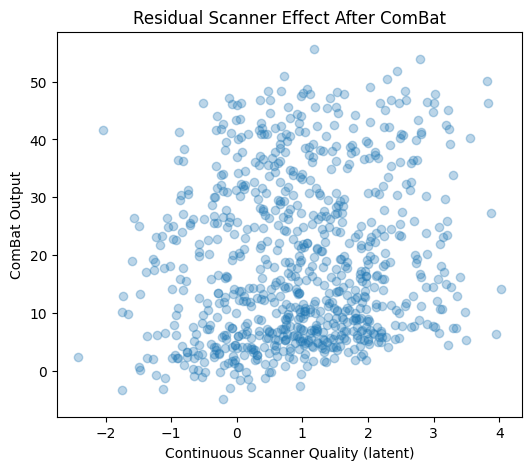

In [122]:
j = 0

plt.figure(figsize=(6,5))

plt.scatter(scanner_quality, Y_combat[j], alpha=0.3)

plt.xlabel("Continuous Scanner Quality (latent)")
plt.ylabel("ComBat Output")
plt.title("Residual Scanner Effect After ComBat")

plt.show()

In [126]:
corr_residual = np.corrcoef(scanner_quality, Y_combat[j])[0,1]
corr_raw = np.corrcoef(scanner_quality, Y_obs[j])[0,1]
corr_bio = np.corrcoef(scanner_quality, true_bio)[0,1]

print("Biological correlation:", corr_bio)
print("Raw observed correlation:", corr_raw)
print("After ComBat:", corr_residual)

Biological correlation: 0.012383172985799796
Raw observed correlation: 0.2530703435567979
After ComBat: 0.1528957536510885
